+------+-------+-------------------+---------+-----------+---------------+------+-------+
|log_id|user_id|          timestamp|     page|     action|     ip_address|device|country|
+------+-------+-------------------+---------+-----------+---------------+------+-------+
|L01509|   U881|2026-04-01 00:12:44|/about-us|   purchase|192.168.247.148|Tablet|Vietnam|
|L00296|   U721|2026-04-01 00:34:32|    /cart|   purchase|192.168.243.133|Mobile|Vietnam|
|L00028|   U795|2026-04-01 01:21:11|    /cart|add_to_cart| 192.168.74.246|Mobile|Vietnam|
|L00575|   U592|2026-04-01 01:59:47|/checkout|add_to_cart| 192.168.94.138|Mobile|Vietnam|
|L01756|   U440|2026-04-01 02:03:05| /contact|       view| 192.168.117.54|Mobile|Vietnam|
+------+-------+-------------------+---------+-----------+---------------+------+-------+
only showing top 5 rows
[*] Tổng số bản ghi trong file: 2000

[*] Số lượt truy cập theo page:
+-------------+-----+
|         page|count|
+-------------+-----+
|        /cart|  258|
|       

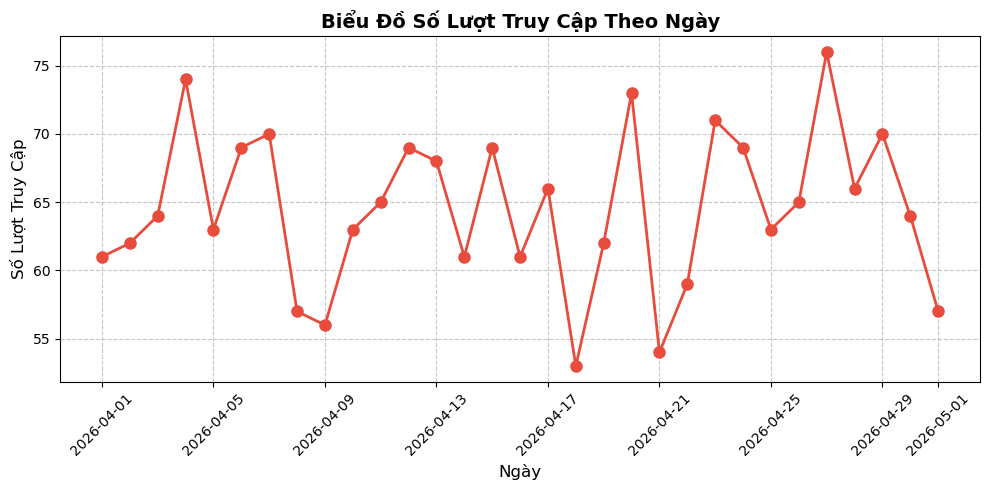

In [6]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import desc, to_date
import pandas as pd
import matplotlib.pyplot as plt

spark = SparkSession.builder.appName("MinIO_Real_WebLogAnalysis").getOrCreate()

hadoop_conf = spark.sparkContext._jsc.hadoopConfiguration()
hadoop_conf.set("fs.s3a.endpoint", "http://minio:9000")
hadoop_conf.set("fs.s3a.access.key", "admin")
hadoop_conf.set("fs.s3a.secret.key", "password123")
hadoop_conf.set("fs.s3a.path.style.access", "true")
hadoop_conf.set("fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
hadoop_conf.set("fs.s3a.connection.ssl.enabled", "false")

hadoop_conf.set("fs.s3a.threads.keepalivetime", "60")
hadoop_conf.set("fs.s3a.connection.establish.timeout", "5000")
hadoop_conf.set("fs.s3a.connection.timeout", "200000")

hadoop_conf.set("fs.s3a.aws.credentials.provider", "org.apache.hadoop.fs.s3a.SimpleAWSCredentialsProvider")
hadoop_conf.set("fs.s3a.multipart.purge.age", "86400")
s3_path = "s3a://logs/web_logs.csv"
df_logs = spark.read.csv(s3_path, header=True, inferSchema=False)

df_logs.show(5)

print(f"[*] Tổng số bản ghi trong file: {df_logs.count()}")

print("\n[*] Số lượt truy cập theo page:")
df_logs.groupBy("page").count().show()

print("\n[*] Top 5 trang có số lượt truy cập cao nhất:")
df_logs.groupBy("page").count().orderBy(desc("count")).show(5)

print("\n[*] Số lượt truy cập theo device:")
df_logs.groupBy("device").count().show()

print("\n[*] Số lượt truy cập theo country:")
df_logs.groupBy("country").count().show()

df_with_date = df_logs.withColumn("date", to_date("timestamp"))
daily_visits = df_with_date.groupBy("date").count().orderBy("date")

print("\n[*] Bảng thống kê số lượt truy cập theo ngày:")
daily_visits.show()

pdf_daily = daily_visits.toPandas()
plt.figure(figsize=(10, 5))
plt.plot(pdf_daily['date'], pdf_daily['count'], marker='o', color='#e74c3c', linewidth=2, markersize=8)
plt.title("Biểu Đồ Số Lượt Truy Cập Theo Ngày", fontsize=14, fontweight='bold')
plt.xlabel("Ngày", fontsize=12)
plt.ylabel("Số Lượt Truy Cập", fontsize=12)
plt.xticks(rotation=45) 
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()